<a href="https://colab.research.google.com/github/jamermj/Nanowires/blob/main/MR_Notebook1_Fixed2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 1 — Data Processing and MR_average Comparison

This notebook processes raw PPMS magnetoresistance data for two datasets, calculates MR using three definitions, computes derivatives, and generates direct MR_average comparison plots for all four samples at each temperature.

## Correct channel mapping

### Dataset 1
| Channel | Sample | Internal name |
|---|---|---|
| CH2 / Bridge 2 | FL2-F | `FL2F` |
| CH3 / Bridge 3 | GN2-2 | `GN22` |

### Dataset 2
| Channel | Sample | Internal name |
|---|---|---|
| CH2 / Bridge 2 | GN2-3 | `GN23` |
| CH3 / Bridge 3 | FL2C3 | `FL2C3` |

## Outputs

- `*_MR_derivatives.csv`
- `R0_summary_all_datasets.csv`
- derivative plots
- `All_samples_MR_average_combined.csv`
- one MR_average comparison plot per temperature
- one 2×3 panel plot comparing all temperatures
- final zip file containing all outputs

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import os
import re
import shutil
import glob
from google.colab import files

# ============================================================
# SETTINGS
# ============================================================

SMOOTH_WINDOW = 15
REMOVE_DATASET1_300K_OUTLIER = True

DATASET_CONFIGS = {
    "dataset1": {
        "match": ["GN2-2", "FL2-F", "dataset1"],

        # Corrected mapping:
        # CH2 / Bridge 2 = FL2-F
        "CH2": "FL2F",
        "CH2_label": "FL2-F",

        # CH3 / Bridge 3 = GN2-2
        "CH3": "GN22",
        "CH3_label": "GN2-2"
    },

    "dataset2": {
        "match": ["GN2-3", "FL2C3", "FL2-C-3", "dataset2"],

        # CH2 / Bridge 2 = GN2-3
        "CH2": "GN23",
        "CH2_label": "GN2-3",

        # CH3 / Bridge 3 = FL2C3
        "CH3": "FL2C3",
        "CH3_label": "FL2C3"
    }
}

# Clean old folders so outputs are not mixed across runs
for folder in ["data_files", "MR_outputs"]:
    if os.path.exists(folder):
        shutil.rmtree(folder)

input_dir = "data_files"
outdir = "MR_outputs"

os.makedirs(input_dir, exist_ok=True)
os.makedirs(outdir, exist_ok=True)

In [2]:
# ============================================================
# UPLOAD BOTH ZIP FILES
# Recommended zip names include dataset1/dataset2 or sample names.
# Example:
#   dataset1_FL2-F_GN2-2.zip
#   dataset2_GN2-3_FL2C3.zip
# ============================================================

uploaded = files.upload()

def identify_dataset(zipname):
    z = zipname.lower()

    for key, cfg in DATASET_CONFIGS.items():
        for term in cfg["match"]:
            if term.lower() in z:
                return key

    raise ValueError(
        f"Could not identify dataset from zip name: {zipname}. "
        "Rename the zip to include dataset1/dataset2 or sample names."
    )

for zipname in uploaded.keys():
    dataset_key = identify_dataset(zipname)

    extract_dir = os.path.join(input_dir, dataset_key)
    os.makedirs(extract_dir, exist_ok=True)

    with zipfile.ZipFile(zipname, 'r') as z:
        z.extractall(extract_dir)

    print(f"Uploaded {zipname} as {dataset_key}")

Saving dataset1_GN2-2_FL2-F_old.zip to dataset1_GN2-2_FL2-F_old.zip
Saving dataset2_GN2-3_FL2C3.zip to dataset2_GN2-3_FL2C3.zip
Uploaded dataset1_GN2-2_FL2-F_old.zip as dataset1
Uploaded dataset2_GN2-3_FL2C3.zip as dataset2


In [3]:
# ============================================================
# HELPER FUNCTIONS
# ============================================================

def find_data_start(filepath):
    with open(filepath, 'r', errors='ignore') as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        if line.strip() == "[Data]":
            return i + 1

    raise ValueError(f"[Data] section not found in {filepath}")


def extract_temperature(filename):
    match = re.search(r'MRat\s*(\d+)K', filename)
    return int(match.group(1)) if match else None


def get_R0_Hminus_Hplus(df, sample_col):
    neg = df[df['Field_Oe'] < 0].copy()
    pos = df[df['Field_Oe'] > 0].copy()

    if len(neg) == 0 or len(pos) == 0:
        raise ValueError(
            f"{sample_col}: need both positive and negative fields. "
            f"Found {len(neg)} negative and {len(pos)} positive."
        )

    idx_neg = neg['Field_Oe'].abs().idxmin()
    idx_pos = pos['Field_Oe'].abs().idxmin()

    H_neg = df.loc[idx_neg, 'Field_Oe']
    R_neg = df.loc[idx_neg, sample_col]

    H_pos = df.loc[idx_pos, 'Field_Oe']
    R_pos = df.loc[idx_pos, sample_col]

    R_avg = 0.5 * (R_neg + R_pos)

    return H_neg, R_neg, H_pos, R_pos, R_avg


def add_MR_and_derivatives(df, sample_col, label):
    H_neg, R_neg, H_pos, R_pos, R_avg = get_R0_Hminus_Hplus(df, sample_col)

    # Three MR definitions
    df[f'MR_{label}_plus'] = (df[sample_col] - R_pos) / R_pos
    df[f'MR_{label}_minus'] = (df[sample_col] - R_neg) / R_neg
    df[f'MR_{label}_average'] = (df[sample_col] - R_avg) / R_avg

    # Smoothed MR curves
    for kind in ["plus", "minus", "average"]:
        df[f'MR_{label}_{kind}_smooth'] = (
            df[f'MR_{label}_{kind}']
            .rolling(window=SMOOTH_WINDOW, center=True, min_periods=1)
            .mean()
        )

    # Derivatives using MR_average_smooth
    df[f'dMRdB_{label}'] = np.gradient(
        df[f'MR_{label}_average_smooth'],
        df['Field_T']
    )

    df[f'd2MRdB2_{label}'] = np.gradient(
        df[f'dMRdB_{label}'],
        df['Field_T']
    )

    return {
        'H_minus_Oe': H_neg,
        'R0_minus': R_neg,
        'H_plus_Oe': H_pos,
        'R0_plus': R_pos,
        'R0_average': R_avg
    }

In [5]:
# ============================================================
# PROCESS RAW FILES
# ============================================================

r0_rows = []
skipped_files = []

for dataset_key, cfg in DATASET_CONFIGS.items():
    dataset_dir = os.path.join(input_dir, dataset_key)

    if not os.path.exists(dataset_dir):
        print(f"Skipping {dataset_key}: no folder found.")
        continue

    for root, dirs, filenames in os.walk(dataset_dir):
        for fname in sorted(filenames):
            if "MRat" not in fname:
                continue

            filepath = os.path.join(root, fname)
            T = extract_temperature(fname)
            base = os.path.splitext(fname)[0]

            print("\n" + "="*90)
            print(f"Processing {dataset_key}: {fname}")
            print("="*90)

            try:
                data_start = find_data_start(filepath)
                df = pd.read_csv(filepath, skiprows=data_start)

                df = df.rename(columns={
                    'Magnetic Field (Oe)': 'Field_Oe',
                    'Bridge 2 Resistivity (Ohm)': cfg["CH2"],
                    'Bridge 3 Resistivity (Ohm)': cfg["CH3"]
                })

                required_cols = ['Field_Oe', cfg["CH2"], cfg["CH3"]]
                missing = [c for c in required_cols if c not in df.columns]

                if missing:
                    raise ValueError(f"Missing required columns after renaming: {missing}")

                df = df[required_cols].dropna()

                for col in required_cols:
                    df[col] = pd.to_numeric(df[col], errors='coerce')

                df = df.dropna().reset_index(drop=True)
                df['Field_T'] = df['Field_Oe'] * 1e-4

                print(f"Field range: {df['Field_Oe'].min():.3f} to {df['Field_Oe'].max():.3f} Oe")
                print(f"N negative points: {(df['Field_Oe'] < 0).sum()}")
                print(f"N positive points: {(df['Field_Oe'] > 0).sum()}")

                r_ch2 = add_MR_and_derivatives(df, cfg["CH2"], cfg["CH2"])
                r_ch3 = add_MR_and_derivatives(df, cfg["CH3"], cfg["CH3"])

                print(f"\n{cfg['CH3_label']}:")
                print(f"  H− = {r_ch3['H_minus_Oe']:.6f} Oe")
                print(f"  R0− = {r_ch3['R0_minus']:.8e}")
                print(f"  H+ = {r_ch3['H_plus_Oe']:.6f} Oe")
                print(f"  R0+ = {r_ch3['R0_plus']:.8e}")
                print(f"  R0_average = {r_ch3['R0_average']:.8e}")

                print(f"\n{cfg['CH2_label']}:")
                print(f"  H− = {r_ch2['H_minus_Oe']:.6f} Oe")
                print(f"  R0− = {r_ch2['R0_minus']:.8e}")
                print(f"  H+ = {r_ch2['H_plus_Oe']:.6f} Oe")
                print(f"  R0+ = {r_ch2['R0_plus']:.8e}")
                print(f"  R0_average = {r_ch2['R0_average']:.8e}")

                r0_rows.append({
                    'Dataset': dataset_key,
                    'Temperature_K': T,
                    'Filename': fname,

                    f'{cfg["CH3_label"]}_H_minus_Oe': r_ch3['H_minus_Oe'],
                    f'{cfg["CH3_label"]}_R0_minus': r_ch3['R0_minus'],
                    f'{cfg["CH3_label"]}_H_plus_Oe': r_ch3['H_plus_Oe'],
                    f'{cfg["CH3_label"]}_R0_plus': r_ch3['R0_plus'],
                    f'{cfg["CH3_label"]}_R0_average': r_ch3['R0_average'],

                    f'{cfg["CH2_label"]}_H_minus_Oe': r_ch2['H_minus_Oe'],
                    f'{cfg["CH2_label"]}_R0_minus': r_ch2['R0_minus'],
                    f'{cfg["CH2_label"]}_H_plus_Oe': r_ch2['H_plus_Oe'],
                    f'{cfg["CH2_label"]}_R0_plus': r_ch2['R0_plus'],
                    f'{cfg["CH2_label"]}_R0_average': r_ch2['R0_average']
                })

                out_csv = os.path.join(
                    outdir,
                    f"{dataset_key}_{base}_MR_derivatives.csv"
                )

                df.to_csv(out_csv, index=False)

            except Exception as e:
                print(f"Skipping {dataset_key}: {fname}")
                print(f"Error: {e}")

                skipped_files.append({
                    'Dataset': dataset_key,
                    'Filename': fname,
                    'Error': str(e)
                })

# ============================================================
# EXPORT R0 SUMMARY
# ============================================================

if len(r0_rows) > 0:
    r0_table = pd.DataFrame(r0_rows).sort_values(
        ['Dataset', 'Temperature_K']
    )

    r0_table.to_csv(
        os.path.join(outdir, "R0_summary_all_datasets.csv"),
        index=False
    )

    print("\nR0 SUMMARY")
    display(r0_table)

else:
    print("\nNo valid MR files were processed.")

if len(skipped_files) > 0:
    skipped_table = pd.DataFrame(skipped_files)

    skipped_table.to_csv(
        os.path.join(outdir, "Skipped_files.csv"),
        index=False
    )

    print("\nSKIPPED FILES")
    display(skipped_table)


Processing dataset1: Ch2FL2-F and Ch-3GN2-2_MRat 100K_+-1Tesla.dat
Field range: nan to nan Oe
N negative points: 0
N positive points: 0
Skipping dataset1: Ch2FL2-F and Ch-3GN2-2_MRat 100K_+-1Tesla.dat
Error: FL2F: need both positive and negative fields. Found 0 negative and 0 positive.

Processing dataset1: Ch2FL2-F and Ch-3GN2-2_MRat 100K_+-2Tesla.dat
Field range: -19999.335 to 19999.524 Oe
N negative points: 162
N positive points: 160

GN2-2:
  H− = -0.170090 Oe
  R0− = 2.72309087e+00
  H+ = 250.051416 Oe
  R0+ = 2.82697920e+00
  R0_average = 2.77503503e+00

FL2-F:
  H− = -0.170090 Oe
  R0− = 2.63630472e-02
  H+ = 250.051416 Oe
  R0+ = 3.15902401e-02
  R0_average = 2.89766436e-02

Processing dataset1: Ch2FL2-F and Ch-3GN2-2_MRat 200K_+-1Tesla.dat
Field range: nan to nan Oe
N negative points: 0
N positive points: 0
Skipping dataset1: Ch2FL2-F and Ch-3GN2-2_MRat 200K_+-1Tesla.dat
Error: FL2F: need both positive and negative fields. Found 0 negative and 0 positive.

Processing dataset1

,Dataset,Temperature_K,Filename,GN2-2_H_minus_Oe,GN2-2_R0_minus,GN2-2_H_plus_Oe,GN2-2_R0_plus,GN2-2_R0_average,FL2-F_H_minus_Oe,FL2-F_R0_minus,...,FL2C3_H_minus_Oe,FL2C3_R0_minus,FL2C3_H_plus_Oe,FL2C3_R0_plus,FL2C3_R0_average,GN2-3_H_minus_Oe,GN2-3_R0_minus,GN2-3_H_plus_Oe,GN2-3_R0_plus,GN2-3_R0_average
2,dataset1,20,Ch2FL2-F and Ch-3GN2-2_MRat 20K_+-2Tesla.dat,-0.093040,8.398329,0.173724,8.404403,8.401366,-0.093040,0.035541,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,dataset1,50,Ch2FL2-F and Ch-3GN2-2_MRat 50K_+-2Tesla.dat,-0.099582,3.587208,0.264584,3.592399,3.589803,-0.099582,0.027389,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,dataset1,100,Ch2FL2-F and Ch-3GN2-2_MRat 100K_+-2Tesla.dat,-0.170090,2.723091,250.051416,2.826979,2.775035,-0.170090,0.026363,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,dataset1,200,Ch2FL2-F and Ch-3GN2-2_MRat 200K_+-2Tesla.dat,-27.503307,0.388438,0.313285,0.384440,0.386439,-27.503307,0.030564,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,dataset1,250,Ch2FL2-F and Ch-3GN2-2_MRat 250K_+-2Tesla.dat,-0.104671,0.067011,0.008723,0.068038,0.067524,-0.104671,0.032998,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,dataset1,300,Ch2FL2-F and Ch-3GN2-2_MRat 300K_+-1Tesla.dat,-0.056697,0.022126,49.988185,0.019453,0.020790,-0.056697,0.017209,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,dataset1,300,Ch2FL2-F and Ch-3GN2-2_MRat 300K_+-2Tesla.dat,-0.023987,0.017376,249.976549,0.022771,0.020074,-0.023987,0.013295,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,dataset2,20,Ch-3-FL2-C-3 and Ch-2-GN2-3 samples_MRat 20K_u...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.277668,0.553204,0.095221,0.555018,0.554111,-0.277668,0.366587,0.095221,0.373628,0.370107
12,dataset2,50,Ch-3-FL2-C-3 and Ch-2-GN2-3 samples_MRat 50K_u...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.188988,0.310018,0.341633,0.312727,0.311373,-0.188988,0.210223,0.341633,0.205211,0.207717
7,dataset2,100,Ch-3-FL2-C-3 and Ch-2-GN2-3 samples_MRat 100K_...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.236963,0.278643,0.590953,0.282450,0.280546,-0.236963,0.183204,0.590953,0.184183,0.183693



SKIPPED FILES


,Dataset,Filename,Error
0,dataset1,Ch2FL2-F and Ch-3GN2-2_MRat 100K_+-1Tesla.dat,FL2F: need both positive and negative fields. ...
1,dataset1,Ch2FL2-F and Ch-3GN2-2_MRat 200K_+-1Tesla.dat,FL2F: need both positive and negative fields. ...
2,dataset1,Ch2FL2-F and Ch-3GN2-2_MRat 20K_+-1Tesla.dat,FL2F: need both positive and negative fields. ...
3,dataset1,Ch2FL2-F and Ch-3GN2-2_MRat 250K_+-1Tesla.dat,FL2F: need both positive and negative fields. ...
4,dataset1,Ch2FL2-F and Ch-3GN2-2_MRat 50K_+-1Tesla.dat,FL2F: need both positive and negative fields. ...


## Combined derivative plots

The next cell plots all four samples on the same derivative graphs at each temperature. These use `MR_average_smooth`.

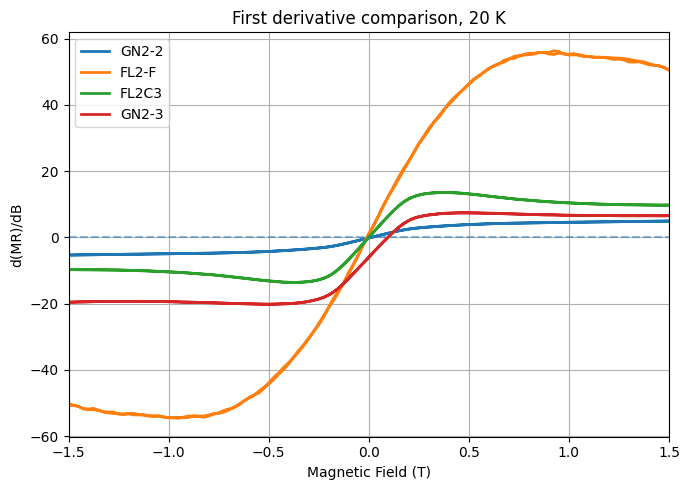

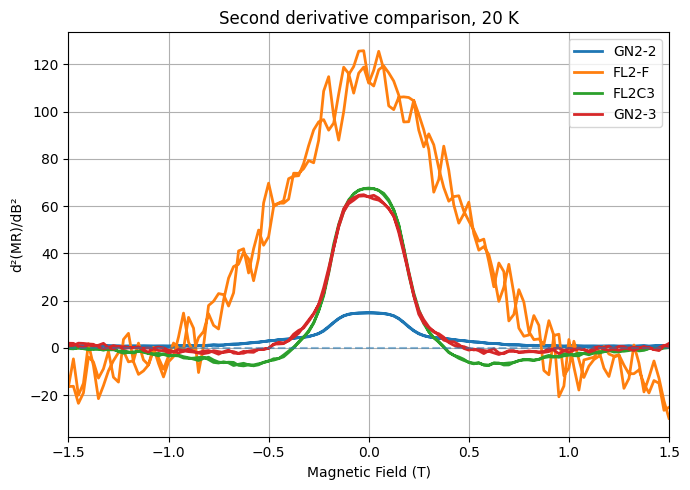

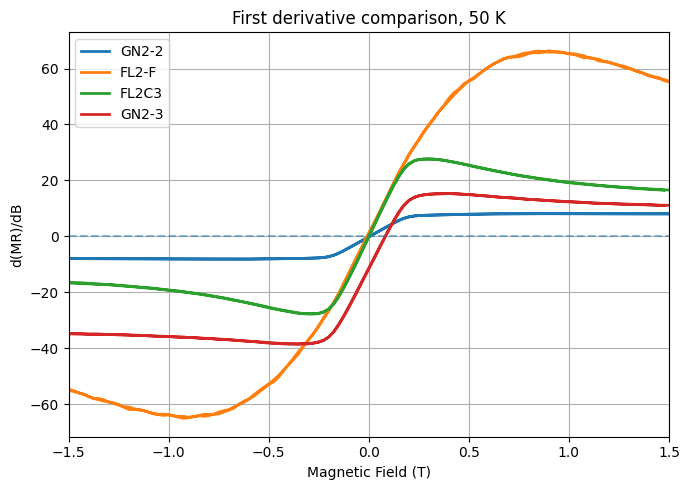

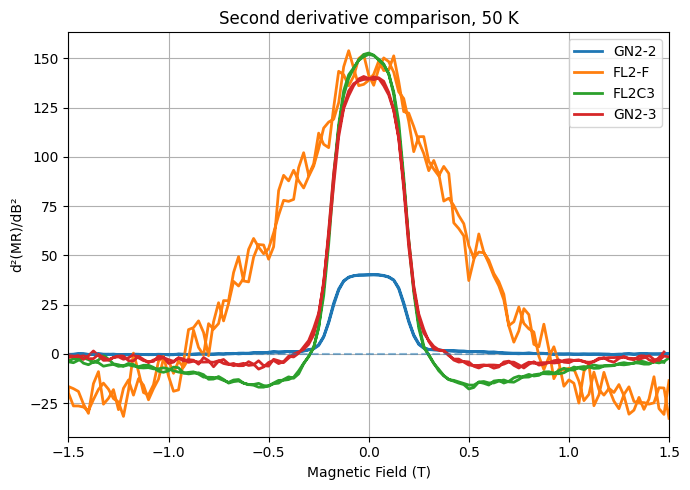

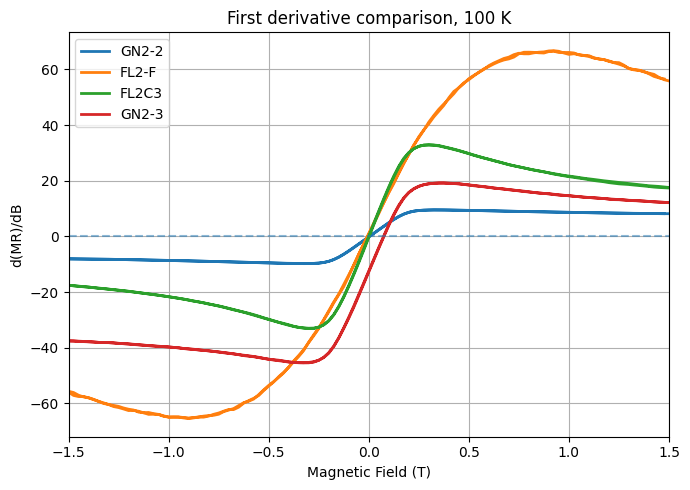

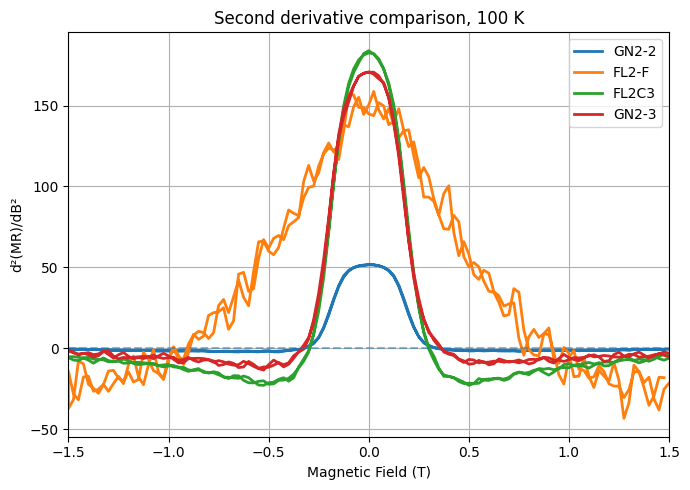

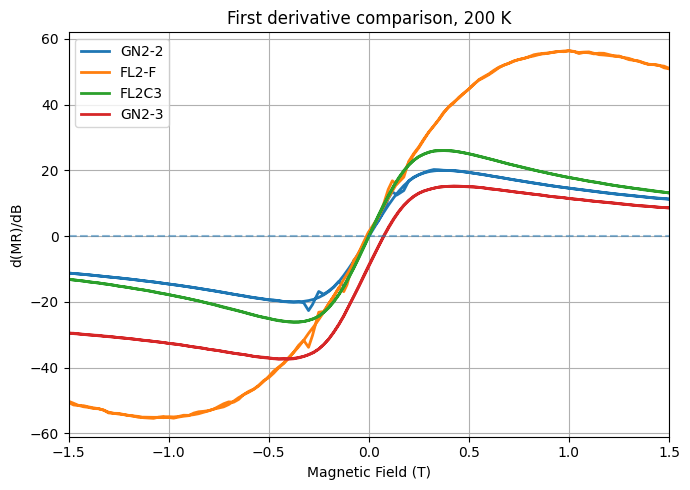

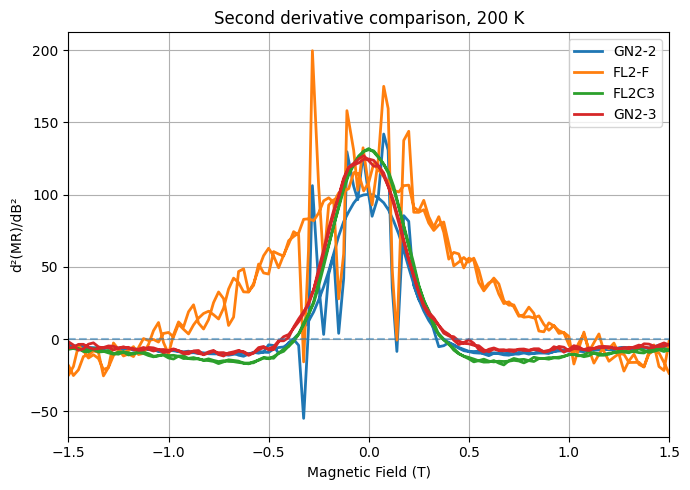

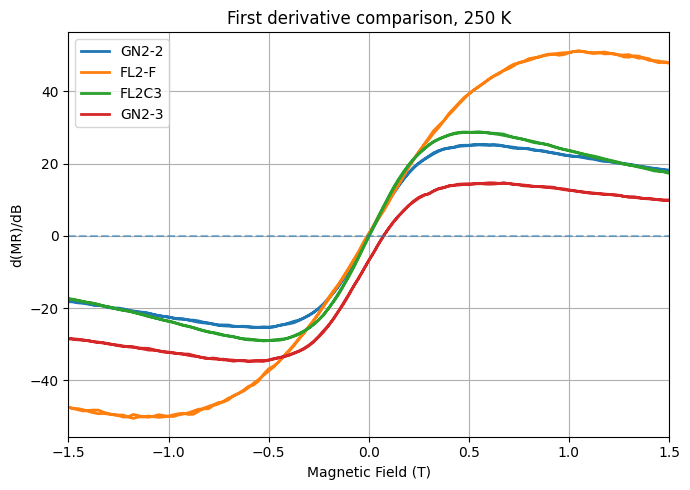

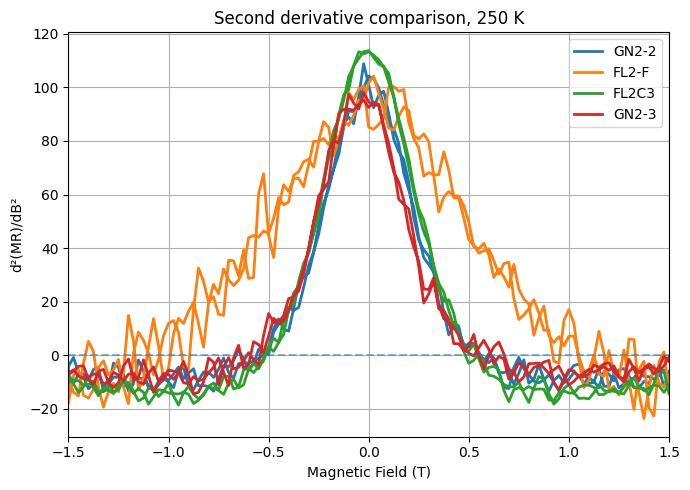

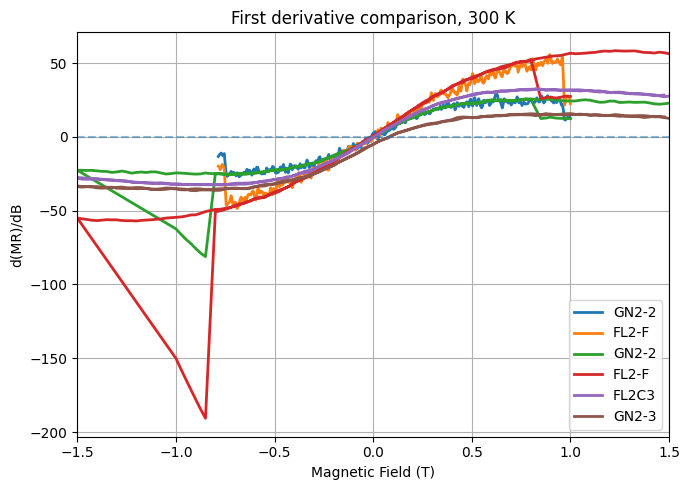

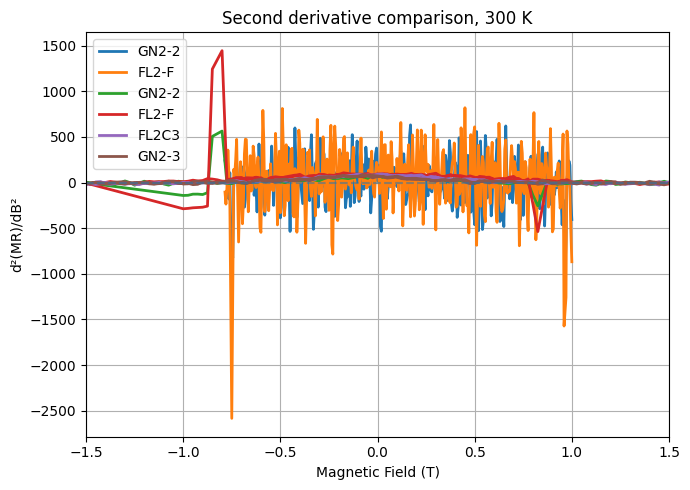

In [6]:
# ============================================================
# COMBINED DERIVATIVE PLOTS
# all four samples on same graph at each temperature
# ============================================================

combined_derivative_data = {}

processed_files = glob.glob(os.path.join(outdir, "*_MR_derivatives.csv"))

for file in sorted(processed_files):
    fname = os.path.basename(file)
    dataset_key = fname.split("_")[0]
    T = extract_temperature(fname)

    df = pd.read_csv(file)
    cfg = DATASET_CONFIGS[dataset_key]

    samples = [
        (cfg["CH3"], cfg["CH3_label"]),
        (cfg["CH2"], cfg["CH2_label"])
    ]

    if T not in combined_derivative_data:
        combined_derivative_data[T] = []

    for internal_sample, sample_label in samples:
        plot_df = df[
            (df["Field_T"] >= -1.5) &
            (df["Field_T"] <=  1.5)
        ].copy()

        # Remove one worst second-derivative outlier only for dataset1 at 300 K
        if (
            REMOVE_DATASET1_300K_OUTLIER
            and dataset_key == "dataset1"
            and T == 300
        ):
            deriv_col = f"d2MRdB2_{internal_sample}"

            if deriv_col in plot_df.columns and len(plot_df) > 5:
                outlier_idx = plot_df[deriv_col].abs().idxmax()
                plot_df = plot_df.drop(index=outlier_idx)

        combined_derivative_data[T].append({
            "dataset": dataset_key,
            "sample_label": sample_label,
            "Field_T": plot_df["Field_T"],
            "dMRdB": plot_df[f"dMRdB_{internal_sample}"],
            "d2MRdB2": plot_df[f"d2MRdB2_{internal_sample}"]
        })

for T in sorted(combined_derivative_data.keys()):

    # First derivative
    plt.figure(figsize=(7,5))

    for item in combined_derivative_data[T]:
        plt.plot(
            item["Field_T"],
            item["dMRdB"],
            linewidth=2,
            label=item["sample_label"]
        )

    plt.axhline(0, linestyle="--", alpha=0.5)
    plt.xlabel("Magnetic Field (T)")
    plt.ylabel("d(MR)/dB")
    plt.title(f"First derivative comparison, {T} K")
    plt.xlim(-1.5, 1.5)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        os.path.join(outdir, f"All_samples_first_derivative_{T}K_pm1p5T.png"),
        dpi=300
    )

    plt.show()

    # Second derivative
    plt.figure(figsize=(7,5))

    for item in combined_derivative_data[T]:
        plt.plot(
            item["Field_T"],
            item["d2MRdB2"],
            linewidth=2,
            label=item["sample_label"]
        )

    plt.axhline(0, linestyle="--", alpha=0.5)
    plt.xlabel("Magnetic Field (T)")
    plt.ylabel("d²(MR)/dB²")
    plt.title(f"Second derivative comparison, {T} K")
    plt.xlim(-1.5, 1.5)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        os.path.join(outdir, f"All_samples_second_derivative_{T}K_pm1p5T.png"),
        dpi=300
    )

    plt.show()

## MR_average comparison plots

These cells create the plots previously planned for Notebook 5 directly inside Notebook 1, so they run in the same Colab runtime as data processing.

In [7]:
# ============================================================
# BUILD COMBINED MR_average DATAFRAME
# All 4 samples at all temperatures
# ============================================================

processed_files = glob.glob(
    os.path.join(outdir, "*_MR_derivatives.csv")
)

all_mravg_data = []

for file in sorted(processed_files):
    fname = os.path.basename(file)
    dataset_key = fname.split("_")[0]
    T = extract_temperature(fname)

    df = pd.read_csv(file)
    cfg = DATASET_CONFIGS[dataset_key]

    samples = [
        (cfg["CH3"], cfg["CH3_label"]),
        (cfg["CH2"], cfg["CH2_label"])
    ]

    for internal_sample, sample_label in samples:
        temp_df = pd.DataFrame({
            "Dataset": dataset_key,
            "Temperature_K": T,
            "Sample": sample_label,
            "Field_T": df["Field_T"],
            "MR_average": df[f"MR_{internal_sample}_average_smooth"]
        })

        all_mravg_data.append(temp_df)

all_mravg_data = pd.concat(
    all_mravg_data,
    ignore_index=True
)

all_mravg_data.to_csv(
    os.path.join(outdir, "All_samples_MR_average_combined.csv"),
    index=False
)

display(all_mravg_data.head())

,Dataset,Temperature_K,Sample,Field_T,MR_average
0,dataset1,100,GN2-2,1.999952,16.309704
1,dataset1,100,GN2-2,1.974978,16.210741
2,dataset1,100,GN2-2,1.949982,16.111607
3,dataset1,100,GN2-2,1.924960,16.012434
4,dataset1,100,GN2-2,1.899995,15.913328


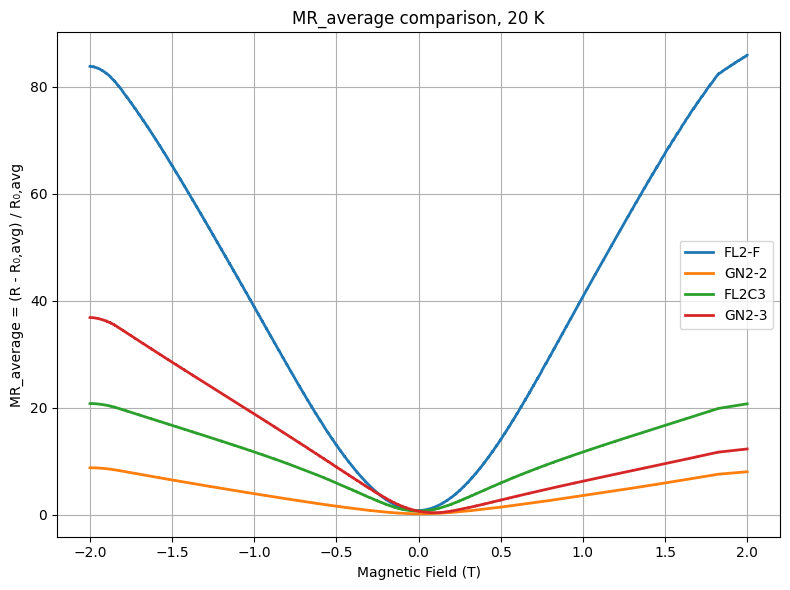

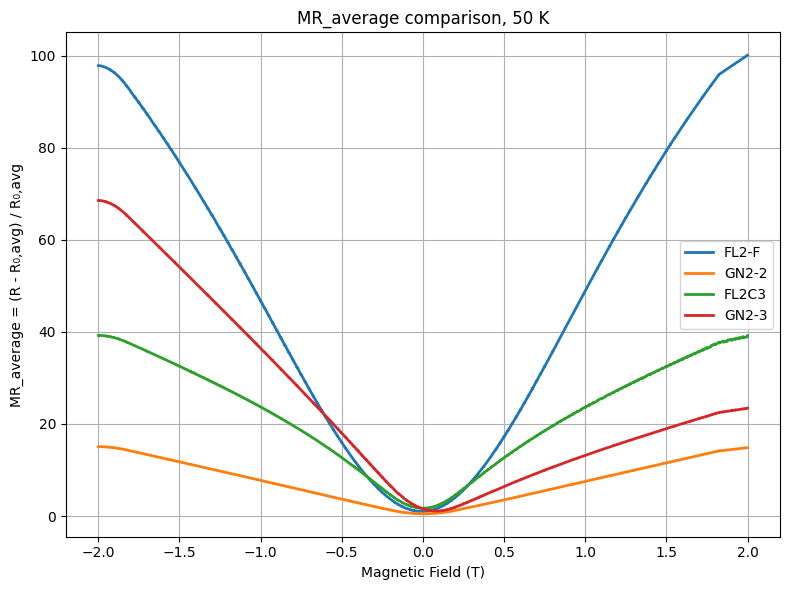

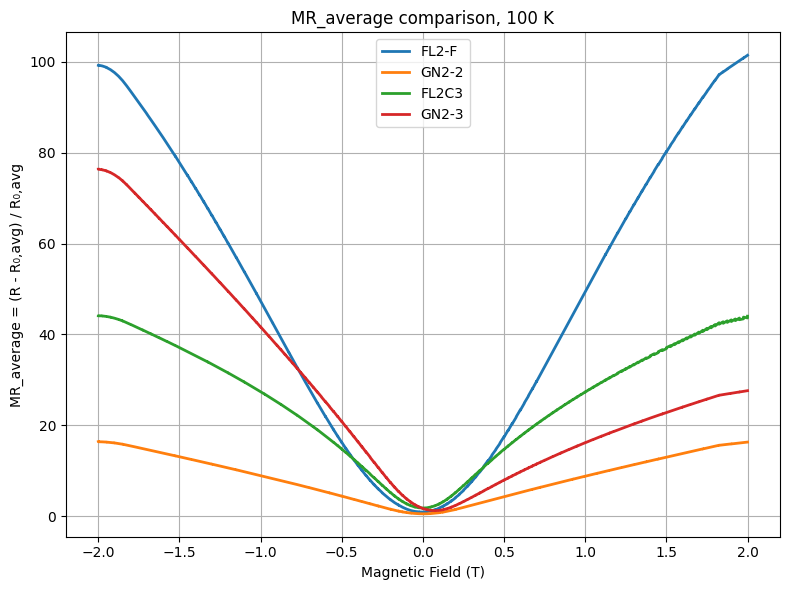

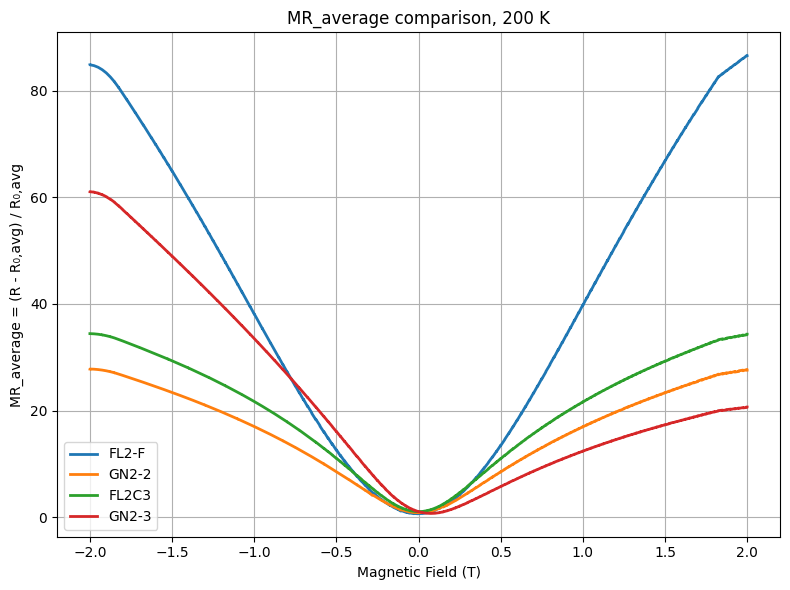

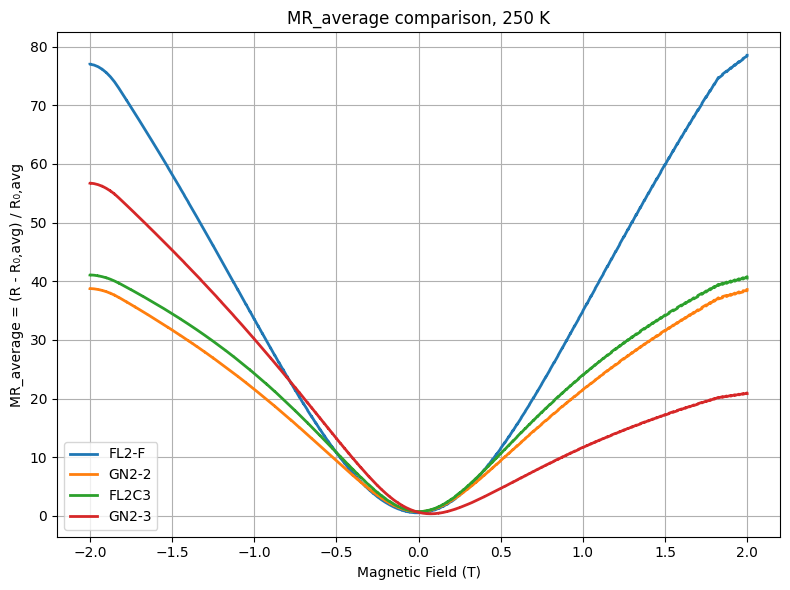

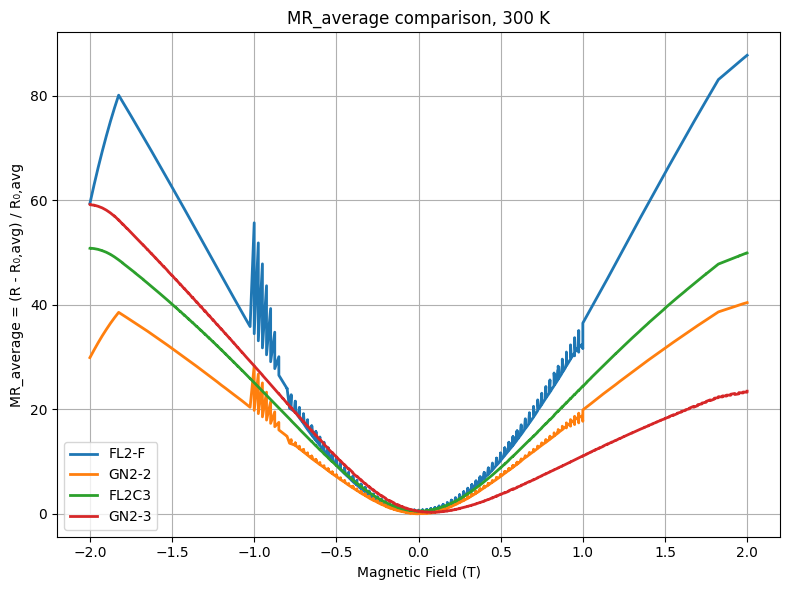

In [8]:
# ============================================================
# PLOT ALL 4 SAMPLES AT EACH TEMPERATURE
# MR_average only
# ============================================================

sample_order = [
    "FL2-F",
    "GN2-2",
    "FL2C3",
    "GN2-3"
]

temperatures = sorted(
    all_mravg_data["Temperature_K"].dropna().unique()
)

for T in temperatures:
    plt.figure(figsize=(8,6))

    temp_data = all_mravg_data[
        all_mravg_data["Temperature_K"] == T
    ]

    for sample in sample_order:
        sub = temp_data[
            temp_data["Sample"] == sample
        ].sort_values("Field_T")

        if len(sub) == 0:
            continue

        plt.plot(
            sub["Field_T"],
            sub["MR_average"],
            linewidth=2,
            label=sample
        )

    plt.xlabel("Magnetic Field (T)")
    plt.ylabel("MR_average = (R - R₀,avg) / R₀,avg")
    plt.title(f"MR_average comparison, {int(T)} K")

    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    outfile = f"MR_average_all_samples_{int(T)}K.png"

    plt.savefig(
        os.path.join(outdir, outfile),
        dpi=300
    )

    plt.show()

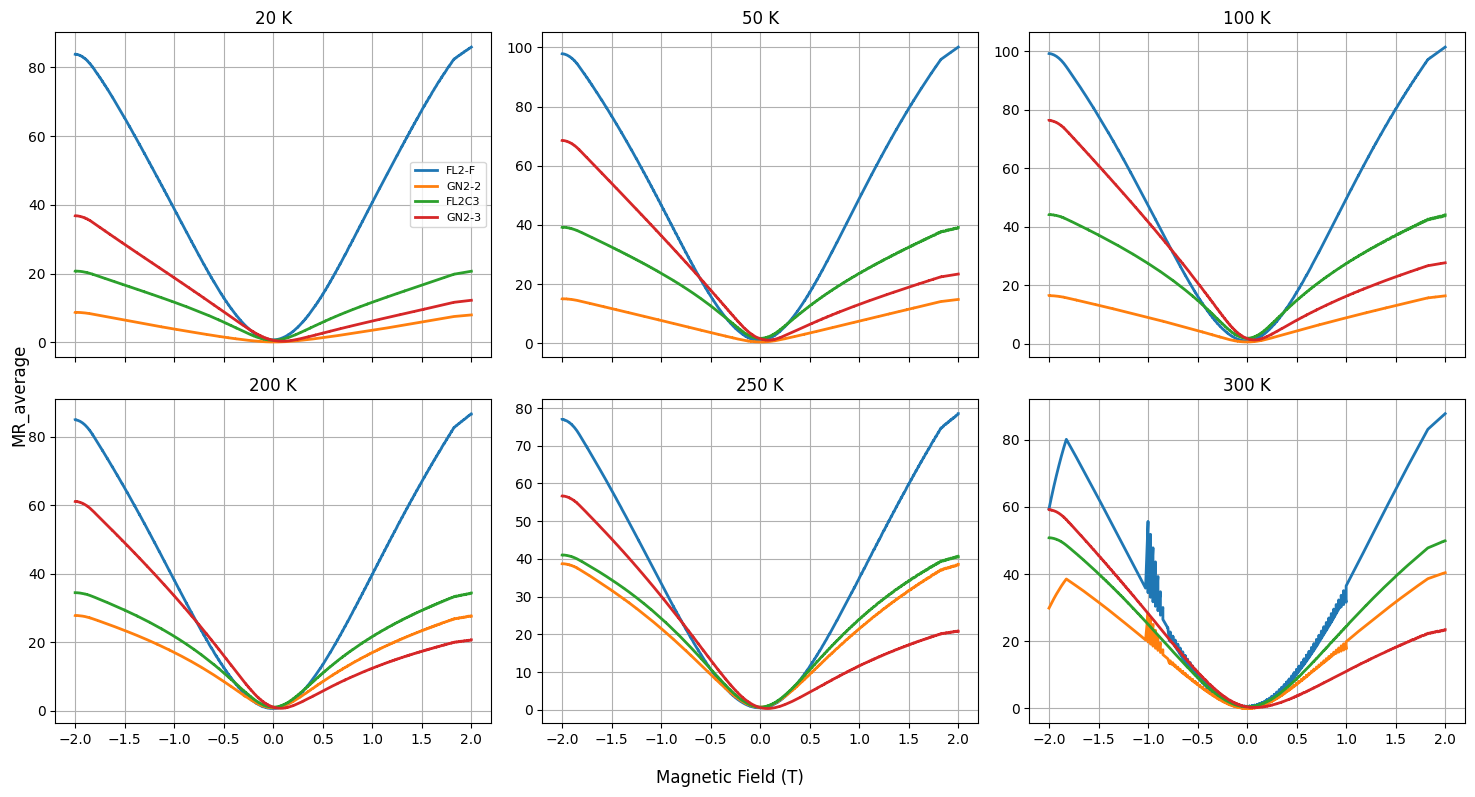

In [9]:
# ============================================================
# 2x3 PANEL FIGURE
# MR_average for all 4 samples at all temperatures
# ============================================================

temperatures = sorted(
    all_mravg_data["Temperature_K"].dropna().unique()
)

fig, axes = plt.subplots(
    2,
    3,
    figsize=(15,8),
    sharex=True,
    sharey=False
)

axes = axes.flatten()

for ax, T in zip(axes, temperatures):
    temp_data = all_mravg_data[
        all_mravg_data["Temperature_K"] == T
    ]

    for sample in sample_order:
        sub = temp_data[
            temp_data["Sample"] == sample
        ].sort_values("Field_T")

        if len(sub) == 0:
            continue

        ax.plot(
            sub["Field_T"],
            sub["MR_average"],
            linewidth=2,
            label=sample
        )

    ax.set_title(f"{int(T)} K")
    ax.grid(True)

for ax in axes[len(temperatures):]:
    ax.axis("off")

axes[0].legend(fontsize=8)

fig.supxlabel("Magnetic Field (T)")
fig.supylabel("MR_average")

plt.tight_layout()

panel_outfile = "MR_average_all_samples_all_temperatures_panel.png"

plt.savefig(
    os.path.join(outdir, panel_outfile),
    dpi=300
)

plt.show()

In [10]:
# ============================================================
# ZIP AND DOWNLOAD OUTPUTS
# ============================================================

zip_out = "MR_Notebook1_outputs.zip"

with zipfile.ZipFile(zip_out, 'w') as z:
    for root, dirs, filenames in os.walk(outdir):
        for f in filenames:
            fullpath = os.path.join(root, f)
            z.write(fullpath, arcname=os.path.relpath(fullpath, outdir))

print(f"Created {zip_out}")
files.download(zip_out)

Created MR_Notebook1_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>